In [1]:
import polars as pl

from deq.plot import line_plot, grouped_bars
from spells import summon, ColSpec, ColType
from spells.config import all_sets


from great_tables import GT

In [2]:
ext = {
    "has_splash": ColSpec(col_type=ColType.GROUP_BY,
                          expr=pl.when(pl.col("splash_colors").is_null()).then(False).otherwise(True)),
    "deck_lands_gb": ColSpec(col_type=ColType.GROUP_BY, expr=lambda names: pl.sum_horizontal([pl.col(f"deck_lands_{name}") for name in names])),
     "deck_spells_hz": ColSpec(col_type=ColType.GROUP_BY, expr=lambda names: pl.sum_horizontal([pl.col(f"deck_spells_{name}") for name in names])),
     "deck_mv_hz": ColSpec(col_type=ColType.GROUP_BY, expr=lambda names: pl.sum_horizontal([pl.col(f"deck_mana_value_{name}") for name in names])),
     "deck_mv_ratio": ColSpec(col_type=ColType.GROUP_BY, expr=pl.col('deck_mv_hz') / pl.col('deck_spells_hz')),
     "deck_mv_class": ColSpec(col_type=ColType.GROUP_BY, expr=(pl.col("deck_mv_ratio") * 4).round() / 4)
}


In [12]:
set_code="EOE"

game_wr = (pl.col('num_won')/pl.col('num_games')).alias('game_wr')
df = summon(
    set_code,
    ["num_won", "num_games"],
    group_by=["deck_lands_gb", "deck_mv_class"],
    extensions=ext, 
    filter_spec={
        '$and':[
            {'lhs': 'num_colors', 'op': '<=', 'rhs': 2},
            #{'main_colors': 'WR'},
            {'player_cohort': 'Top'},
            {"lhs": "format_day", "op":">=", "rhs": 1},
        ]
    }
).sort('num_games', descending=True)

df = df.with_columns(game_wr)


In [13]:
group_df = df.drop('deck_mv_class').group_by('deck_lands_gb').sum()
group_df = group_df.with_columns(game_wr).drop('num_won')


In [17]:
pl.Config.set_tbl_rows(1000)
df.sort('num_games', descending=True)

deck_lands_gb,deck_mv_class,num_won,num_games,game_wr
i8,f64,u32,u32,f64
17,3.25,18002,28669,0.627926
17,3.0,15057,23977,0.627977
17,2.75,9341,14973,0.623856
17,3.5,9310,14798,0.629139
16,3.0,2803,4340,0.645853
16,2.75,2566,4055,0.632799
17,3.75,2436,3961,0.614996
17,2.5,2303,3630,0.634435
16,3.25,1577,2536,0.621845


In [14]:
pivot = df.filter(  
    pl.col('num_games') > 2000).pivot(   
    on="deck_lands_gb", 
    index="deck_mv_class", 
    values="game_wr").sort(
    "deck_mv_class").rename(
    {'deck_mv_class': 'Deck Average Mana Value'})



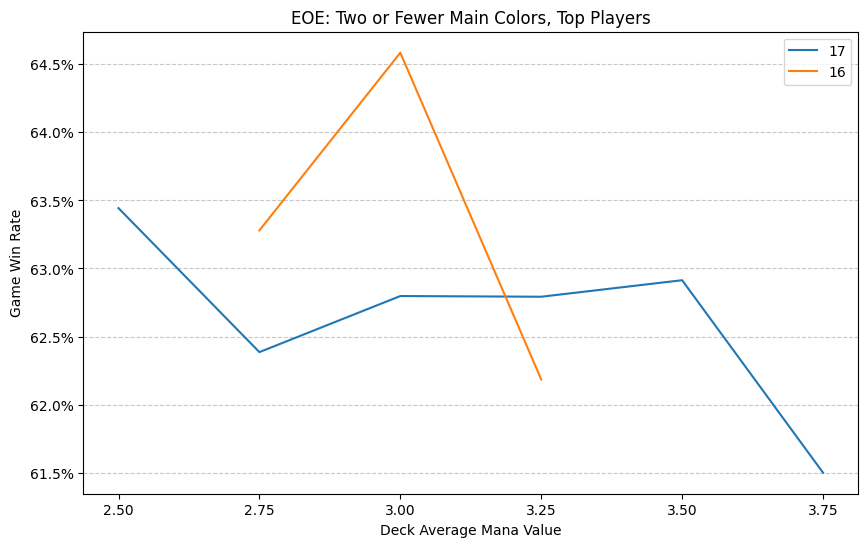

In [15]:
line_plot(
    pivot, 
    title=f"{set_code}: Two or Fewer Main Colors, Top Players",
    is_pct=True,
    y_label="Game Win Rate"
)


In [7]:
df = summon(
    "EOE", 
    ["game_wr", "num_games"],
    group_by=["deck_lands_gb"],
    extensions=ext, 
    filter_spec={
        '$and':[
            {'lhs': 'num_colors', 'op': '<=', 'rhs': 5},
            {"player_cohort": "Top"},
            {"lhs": "format_day", "op":">", "rhs": 6}
        ]
    }
).sort('num_games', descending=True)


In [9]:
df

deck_lands_gb,game_wr,num_games
i8,f64,u32
17,0.624009,68334
16,0.633207,10022
18,0.631735,3044
15,0.619289,394
19,0.605263,190
20,0.673469,49
14,0.470588,17
21,0.5,6


In [8]:
GT(df.with_columns(game_wr).drop("num_won")
   .sort("deck_lands_gb").filter(pl.col('num_games') > 100).rename(
    {'deck_lands_gb': 'Num Lands', "has_splash":"Splash", 'game_wr': 'Game WR', 'num_games': 'Num Games'}
)).fmt_percent(columns="Game WR").tab_header(
    title="Boros", subtitle="Win Rate by Number of Lands in Deck, Top Players")




ColumnNotFoundError: num_won

Resolved plan until failure:

	---> FAILED HERE RESOLVING 'with_columns' <---
DF ["deck_lands_gb", "game_wr", "num_games"]; PROJECT */3 COLUMNS